In [5]:
import os
import pandas as pd
from pathlib import Path
import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as ticker
import tqdm
import mne
os.chdir("D:/TUSZ_DataLake")

# Estandarización Espacial y Metodología de Montaje Bipolar

La auditoría de la estrategia de segmentación inicial reveló inconsistencias estructurales críticas: 26 pacientes presentaron esquemas de montaje incoherentes y 13 pacientes mostraron datos corruptos (NaNs) en variables esenciales. El fallo se concentró sistemáticamente en la derivación central Fz-Cz, afectando métricas fundamentales como el Line Length y la potencia espectral. Estos errores sugieren una pérdida de electrodos clave en el montaje original o una ruptura en la cadena de procesamiento para registros que no cumplen con la topografía estándar.

Este diagnóstico evidenció que la asunción de homogeneidad en el corpus era errónea, actuando como el catalizador para un estudio detallado de las características de las sesiones. En lugar de proceder con el entrenamiento de modelos predictivos sobre una base de datos comprometida, se priorizó una caracterización exhaustiva del config_type y del número de canales (n_channels).

A continuación, se presenta la distribución del número de canales EEG registrados a través de la totalidad de las sesiones del corpus TUSZ. Esta visualización permite identificar la variabilidad estructural del dataset, resaltando la predominancia de los montajes estándar frente a los registros de baja densidad que motivaron la auditoría de integridad del pipeline.

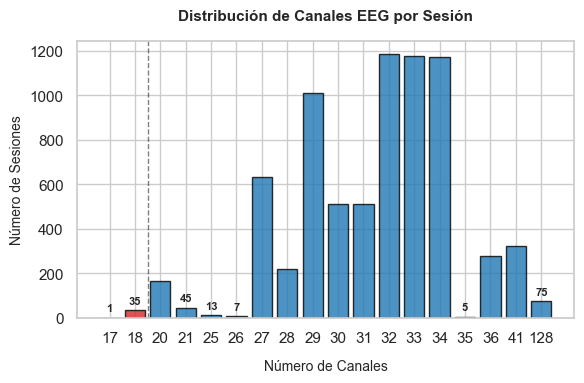

In [24]:
metadata_path = Path(r"D:\TUSZ_DataLake\02_Metadata\metadata_sessions.parquet")
df_meta = pd.read_parquet(metadata_path)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

n_counts = df_meta['n_channels'].value_counts().sort_index().reset_index()
n_counts.columns = ['n_channels', 'count']

colors = ['#d62728' if x < 19 else '#1f77b4' for x in n_counts['n_channels']]

bars = plt.bar(n_counts['n_channels'].astype(str), n_counts['count'], 
               color=colors, edgecolor='black', alpha=0.8)
for bar in bars:
    height = bar.get_height()
    if height < 100: 
        plt.text(bar.get_x() + bar.get_width()/2., height + 20,
                 f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.title("Distribución de Canales EEG por Sesión", fontsize=11, fontweight='bold', pad = 15)
plt.xlabel("Número de Canales", fontsize=10, labelpad = 10)
plt.ylabel("Número de Sesiones", fontsize=10)

# Línea divisoria técnica en el umbral de integridad
plt.axvline(x=1.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

El análisis de representatividad revela que las 36 sesiones inconsistentes (apenas el 0.49% del total) están vinculadas a solo 8 pacientes, lo que representa el 1.2% de la población total del corpus. Esta alta concentración sugiere que el problema no es una degradación aleatoria de los datos, sino un factor técnico persistente en registros específicos. Un estudio detallado indica que esta anomalía está estrechamente ligada al tipo de configuración reportado por el TUSZ. A continuación, se grafica la proporción de sesiones con menos de 19 canales desglosada por config_type, lo que permitirá confirmar si el error es exclusivo de un protocolo de adquisición particular.

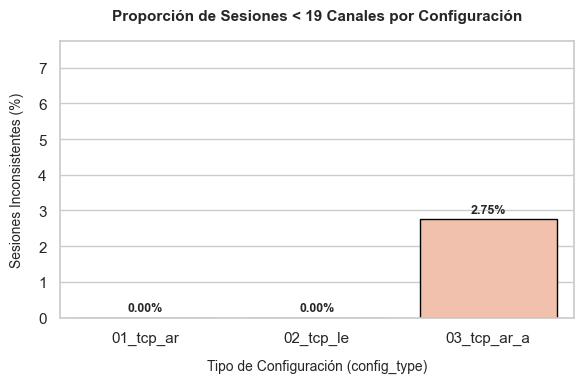

In [28]:
df_meta['is_low_res'] = df_meta['n_channels'] < 19
config_stats = df_meta.groupby('config_type')['is_low_res'].value_counts(normalize=True).unstack().fillna(0)
config_stats['percentage_low_res'] = config_stats[True] * 100

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=config_stats.index, 
    y=config_stats['percentage_low_res'],
    hue=config_stats.index, 
    palette="Reds_r",
    edgecolor='black',
    legend=False 
)

plt.title("Proporción de Sesiones < 19 Canales por Configuración", fontsize=11, fontweight='bold', pad = 15)
plt.xlabel("Tipo de Configuración (config_type)", fontsize=10, labelpad = 10)
plt.ylabel("Sesiones Inconsistentes (%)", fontsize=10, labelpad = 10)
plt.ylim(0, max(config_stats['percentage_low_res']) + 5)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

El análisis confirma que la totalidad de las inconsistencias estructurales se concentran de forma exclusiva en la configuración 03_tcp_ar_a. Este protocolo, caracterizado por el uso de una Referencia Promediada (Average Reference), es históricamente el más heterogéneo del corpus TUSZ, abarcando desde registros de alta densidad hasta montajes clínicos simplificados. La presencia de sesiones con 17 y 18 canales en este grupo responde probablemente a protocolos de emergencia o fallos técnicos en electrodos críticos durante la adquisición original. A pesar de esta variabilidad, se ha determinado mantener las sesiones del grupo 03_tcp_ar_a que cumplen con el estándar de $\ge 19$ canales. Esta decisión se fundamenta en dos pilares: primero, la preservación del 18% del volumen total del dataset (1,273 sesiones adicionales), evitando una pérdida masiva de diversidad biológica; y segundo, la capacidad de nuestra re-referenciación bipolar longitudinal para neutralizar matemáticamente las diferencias entre montajes de referencia promediada y los de referencia en orejas (LE). De este modo, garantizamos un Data Lake balanceado, íntegro y espacialmente consistente.

Más allá de la reducción de ruido ambiental y la mitigación de la conducción de volumen, el uso del montaje Bipolar Longitudinal ("Double Banana") actúa como el mecanismo definitivo de estandarización técnica. El corpus TUSZ es intrínsecamente heterogéneo al mezclar registros con Referencia Promediada (01_tcp_ar y 03_tcp_ar_a) y registros con Referencia en Orejas (02_tcp_le). Dado que cada protocolo establece un "cero" eléctrico distinto, los voltajes brutos no son comparables entre sesiones.El principio de diferencia de potencial resuelve esta inconsistencia mediante la cancelación de la referencia común. Si consideramos dos electrodos adyacentes $i$ y $j$ registrados bajo configuraciones distintas, sus potenciales medidos se definen como:

* En configuración AR (01 y 03): $V_{i, AR} = S_i + Ref_{AR}$  y  $V_{j, AR} = S_j + Ref_{AR}$
  
* En configuración LE (02): $V_{i, LE} = S_i + Ref_{LE}$  y  $V_{j, LE} = S_j + Ref_{LE}$

Al aplicar la re-referenciación digital hacia el montaje bipolar, calculamos la diferencia:$$V_{diff} = (S_i + Ref) - (S_j + Ref) = S_i - S_j$$Independencia de la Referencia: Como se observa en la ecuación, el término del potencial de referencia ($Ref$) se anula completamente por sustracción. El resultado, $S_i - S_j$, representa la actividad cortical local pura y es matemáticamente idéntico sin importar si el origen es un protocolo AR o LE. Esta propiedad es la que nos permite fusionar los tres grupos en un único Data Lake homogéneo y coherente, garantizando que el modelo aprenda patrones electroencefalográficos reales y no sesgos derivados del equipo de adquisición.

Si bien el filtrado inicial por cantidad de señales permitió identificar a un grupo de 8 pacientes cuyas sesiones presentaban un déficit crítico (menos de 19 canales), la auditoría técnica extendida reportó inconsistencias en un total de 27 sesiones adicionales. Este hallazgo permite establecer la hipótesis de que existen registros donde, a pesar de contar con una densidad de electrodos nominalmente suficiente ($n \geq 19$), las etiquetas o posiciones físicas de los sensores no se corresponden con el Sistema Internacional 10-20. Esta discrepancia técnica hace imperativa una revisión profunda de la topografía de cada registro, asegurando que el montaje bipolar longitudinal sea factible y anatómicamente coherente antes de proceder a la extracción de características.

In [6]:
from tqdm.auto import tqdm
import warnings
def validate_montage_integrity(root_path):
    """
    Audita el Data Lake para identificar sesiones que, teniendo al menos 19 canales,
    no cumplen con los electrodos específicos del Sistema 10-20.
    """
    root = Path(root_path)
    edf_files = list(root.rglob("*.edf"))
    
    required_electrodes = {
        'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 
        'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ'
    }
    
    synonyms = {
        'T7': 'T3', 'T8': 'T4',
        'P7': 'T5', 'P8': 'T6'
    }
    
    inconsistent_sessions = []

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*match the file size.*")
        
        for edf_path in tqdm(edf_files, desc="Auditoría de montajes"):
            try:
                raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
                
                if len(raw.ch_names) < 19:
                    continue
                
                normalized_channels = []
                for ch in raw.ch_names:
                    clean_name = ch.replace('EEG ', '').split('-')[0].strip().upper()
                    clean_name = synonyms.get(clean_name, clean_name)
                    normalized_channels.append(clean_name)
                
                missing = required_electrodes - set(normalized_channels)
                
                if missing:
                    inconsistent_sessions.append({
                        'file_path': str(edf_path),
                        'n_channels_total': len(raw.ch_names),
                        'missing_electrodes': sorted(list(missing)),
                        'status': 'Topography Incomplete'
                    })
                    
            except Exception as e:
                inconsistent_sessions.append({
                    'file_path': str(edf_path),
                    'error': str(e),
                    'status': 'Read Error'
                })

    return pd.DataFrame(inconsistent_sessions)

In [51]:
path_raw = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
df_audit = validate_montage_integrity(path_raw)

Auditoría de montajes:   0%|          | 0/7364 [00:00<?, ?it/s]

La revisión de la totalidad del conjunto de datos permitió identificar 213 sesiones inconsistentes con el Sistema Internacional 10-20 debido a fallos estructurales. Estas sesiones involucran a 19 pacientes que, al sumarse a los 8 sujetos detectados inicialmente con un conteo insuficiente de canales, consolidan los 27 pacientes reportados en la auditoría técnica. Este hallazgo confirma que las fallas de datos no fueron errores de software, sino discrepancias físicas en el montaje de adquisición; por ello, el siguiente paso es verificar específicamente cuáles son los canales faltantes en estos registros.

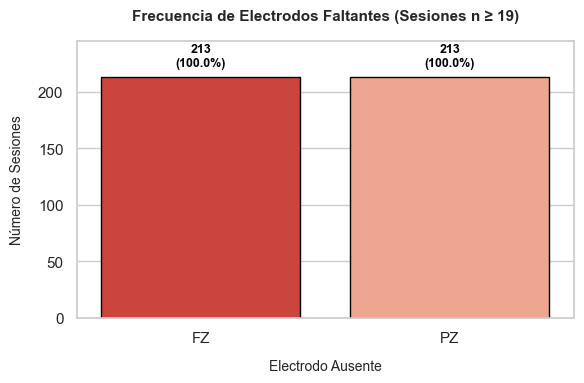

In [50]:
missing_series = df_audit['missing_electrodes'].explode()
missing_counts = missing_series.value_counts()
total_audit = len(df_audit)

df_plot = missing_counts.reset_index()
df_plot.columns = ['electrode', 'count']
df_plot['percentage'] = (df_plot['count'] / total_audit) * 100

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=df_plot,
    x='electrode', 
    y='count',
    hue='electrode',
    palette="Reds_r",
    edgecolor='black',
    legend=False
)

plt.title("Frecuencia de Electrodos Faltantes (Sesiones n ≥ 19)", fontsize=11, fontweight='bold', pad=15)
plt.xlabel("Electrodo Ausente", fontsize=10, labelpad=10)
plt.ylabel("Número de Sesiones", fontsize=10, labelpad=10)

plt.ylim(0, df_plot['count'].max() * 1.15)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_audit) * 100
    ax.annotate(f'{height:.0f}\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points',
                fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

El análisis técnico reveló que en la totalidad de las sesiones afectadas se omitieron los canales Fz y Pz. En un montaje de EEG convencional, estos electrodos representan los puntos frontal y parietal de la línea media sagital, actuando como ejes centrales para la evaluación de la actividad cerebral interhemisférica.  Dada la importancia de estos sensores para la integridad del montaje, el siguiente paso consiste en verificar si esta omisión constituye un error sistemático que afecta a la totalidad de las sesiones de los pacientes identificados o si, por el contrario, se limita a una pequeña proporción de sus registros, permitiendo así recuperar los datos de las sesiones técnicamente correctas.

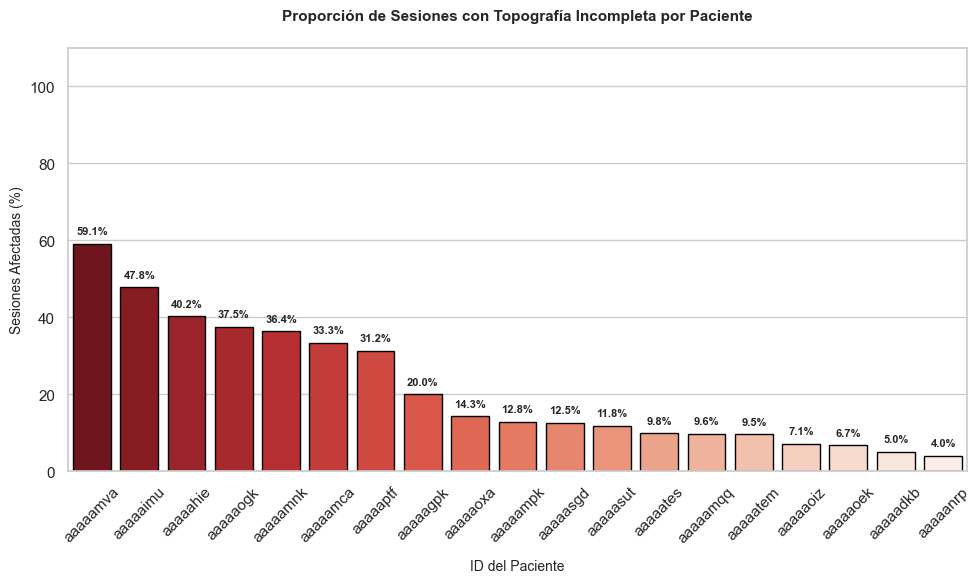

In [49]:
df_pts = pd.read_parquet(r"D:\TUSZ_DataLake\02_Metadata\metadata_patients.parquet")
df_meta_full = pd.merge(
    df_meta, 
    df_pts[['patient_num_id', 'patient_id']], 
    on='patient_num_id', 
    how='left'
)

afectados_ids = df_audit['patient_id'].unique()

total_sesiones_por_paciente = df_meta_full[
    df_meta_full['patient_id'].isin(afectados_ids)
].groupby('patient_id').size().reset_index(name='total_sessions')

fallos_por_paciente = df_audit.groupby('patient_id').size().reset_index(name='affected_sessions')

df_impacto = pd.merge(total_sesiones_por_paciente, fallos_por_paciente, on='patient_id')
df_impacto['proportion_affected'] = (df_impacto['affected_sessions'] / df_impacto['total_sessions']) * 100

df_impacto = df_impacto.sort_values(by='proportion_affected', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_impacto,
    x='patient_id',
    y='proportion_affected',
    hue='patient_id',
    palette="Reds_r",
    edgecolor='black',
    legend=False
)

plt.title("Proporción de Sesiones con Topografía Incompleta por Paciente", fontsize=11, fontweight='bold', pad=20)
plt.xlabel("ID del Paciente", fontsize=10, labelpad = 10)
plt.ylabel("Sesiones Afectadas (%)", fontsize=10)
plt.xticks(rotation=45)
plt.ylim(0, 110)

# Anotaciones de porcentaje
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

El análisis de impacto por sujeto reveló una variabilidad significativa en la calidad de los registros, destacando que ningún paciente tuvo el 100% de sus sesiones comprometidas. Si bien se identificaron casos aislados donde la afectación supera el 50%, esta tendencia no constituye la regla general del dataset. Este hallazgo es de suma importancia, ya que confirma que la inconsistencia no es una limitación intrínseca de los pacientes, sino un factor variable dependiente de la sesión

En sintesis, la revisión detallada del conjunto de datos permitió localizar con precisión los 27 casos reportados originalmente en la auditoría técnica, resolviendo las incertidumbres respecto a la integridad del flujo de procesamiento. Los hallazgos confirman que las inconsistencias detectadas se derivan estrictamente de discrepancias físicas con el sistema internacional 10-20 durante la adquisición, descartando cualquier fallo en la extracción de características o en la aplicación de los filtros digitales. Esta distinción resulta crucial, pues deslinda el rendimiento de las herramientas de software de las limitaciones estructurales presentes en el montaje clínico de origen.

Bajo esta premisa, la exclusión de los registros que no cumplen con la topografía estándar se establece como la medida más robusta para garantizar la fiabilidad del entrenamiento. Es fundamental señalar que esta depuración no conlleva la pérdida de ningún paciente en el estudio, dado que la metodología considera cada sesión como una unidad de análisis independiente. Al procesar únicamente los registros que mantienen una coherencia espacial verificable, se asegura una base de datos higienizada que permite al modelo aprender de patrones biológicos reales, sin el sesgo introducido por sensores inexistentes o montajes incompletos.

# Segmentación Temporal y Estrategias de Aumento de Datos

In [69]:
def get_comparative_audit_dfs(csv_path: str, parquet_path: str):
    """
    Realiza una auditoría comparativa entre la distribución temporal original (CSVs)
    y la distribución de ventanas generadas tras el procesamiento (Parquet).
    """
    
    # 1. CONFIGURACIÓN DE MAPEO CLÍNICO
    mapping = {
        'bckg': 'BACKGROUND',
        'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
        'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED', 
        'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
    }

    # 2. AUDITORÍA NATURAL (DURACIÓN EN SEGUNDOS)
    print("Analizando distribucion NATURAL (basada en tiempo total de registros)")
    csv_files = list(Path(csv_path).rglob("*.csv"))
    durations = {'BACKGROUND': 0.0, 'FOCAL': 0.0, 'GENERALIZED': 0.0}

    for f in tqdm(csv_files, desc="Procesando archivos CSV"):
        try:
            df = pd.read_csv(f, comment='#')
            df.columns = df.columns.str.strip()
            df['duration'] = df['stop_time'] - df['start_time']
            df['mapped'] = df['label'].str.strip().map(lambda x: mapping.get(x, 'OTRO'))
            
            group_sums = df.groupby('mapped')['duration'].sum()
            for label, total_d in group_sums.items():
                if label in durations:
                    durations[label] += total_d
        except Exception:
            continue

    # 3. AUDITORÍA PROCESADA (CONTEO DE VENTANAS)
    print("\nAnalizando distribucion PROCESADA (basada en ventanas generadas)")
    parquet_files = list(Path(parquet_path).rglob("*.parquet"))
    windows = {'BACKGROUND': 0, 'FOCAL': 0, 'GENERALIZED': 0}

    for f in tqdm(parquet_files, desc="Procesando archivos Parquet"):
        try:
            df_label = pd.read_parquet(f, columns=['label'])
            df_label['mapped'] = df_label['label'].map(lambda x: mapping.get(x, 'OTRO'))
            
            counts = df_label['mapped'].value_counts()
            for label, count in counts.items():
                if label in windows:
                    windows[label] += count
        except Exception:
            continue

    # 4. CONSTRUCCIÓN DE DATAframes DE RESULTADOS
    
    # Distribución Natural
    total_sec = sum(durations.values())
    df_natural = pd.DataFrame({
        'Label': durations.keys(),
        'Segundos': durations.values(),
        'Prop_Original (%)': [round((v/total_sec*100), 2) if total_sec > 0 else 0 for v in durations.values()]
    }).set_index('Label').sort_values(by='Segundos', ascending=False)

    # Distribución Procesada
    total_win = sum(windows.values())
    df_processed = pd.DataFrame({
        'Label': windows.keys(),
        'Ventanas': windows.values(),
        'Prop_Procesada (%)': [round((v/total_win*100), 2) if total_win > 0 else 0 for v in windows.values()]
    }).set_index('Label').sort_values(by='Ventanas', ascending=False)

    return df_natural, df_processed

def plot_class_comparison(df_natural, df_processed):
    """
    Gráfica comparativa de distribución de clases siguiendo el estándar
    estético de la auditoría técnica.
    """
    # 1. Configuración de estilo global
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
    
    # Paleta clínica consistente
    palette = {"BACKGROUND": "#34495e", "FOCAL": "#e74c3c", "GENERALIZED": "#f1c40f"}
    
    # Determinar el límite Y máximo para ambas gráficas
    max_val = max(df_natural['Prop_Original (%)'].max(), df_processed['Prop_Procesada (%)'].max())

    # --- GRÁFICA 1: DISTRIBUCIÓN NATURAL ---
    sns.barplot(
        x=df_natural.index, 
        y=df_natural['Prop_Original (%)'], 
        ax=ax1, 
        hue=df_natural.index,
        palette=palette,
        edgecolor='black',
        legend=False
    )
    ax1.set_title("Distribución natural", fontsize=11, fontweight='bold', pad=15)
    ax1.set_ylabel("Proporción del Dataset (%)", fontsize=10, labelpad=10)
    ax1.set_xlabel("Clase Clínica", fontsize=10, labelpad=10)
    ax1.set_ylim(0, max_val + 10)

    # --- GRÁFICA 2: DISTRIBUCIÓN PROCESADA ---
    sns.barplot(
        x=df_processed.index, 
        y=df_processed['Prop_Procesada (%)'], 
        ax=ax2, 
        hue=df_processed.index,
        palette=palette,
        edgecolor='black',
        legend=False
    )
    ax2.set_title("Estrategia de Ventaneo Diferencial", fontsize=11, fontweight='bold', pad=15)
    ax2.set_xlabel("Clase Clínica", fontsize=10, labelpad=10)
    ax2.set_ylabel("") # Comparten eje Y
    ax2.set_ylim(0, max_val + 10)

    # 2. Aplicar Anotaciones (Exactamente igual al layout de ejemplo)
    for ax in [ax1, ax2]:
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.2f}%', 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', 
                            xytext=(0, 7), # Valor del layout de ejemplo
                            textcoords='offset points',
                            fontsize=12, fontweight='bold')

    
    plt.tight_layout()
    plt.show()

In [59]:
CSV_PATH = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
PARQUET_PATH = r"C:\Users\jcami\Downloads\04_TUSZ_Features_ML\version=v1_raw_labels"
    
# --- AQUÍ RECIBES TUS VARIABLES ---
df_original, df_final = get_comparative_audit_dfs(CSV_PATH, PARQUET_PATH)

Analizando distribucion NATURAL (basada en tiempo total de registros)


Procesando archivos CSV:   0%|          | 0/7364 [00:00<?, ?it/s]


Analizando distribucion PROCESADA (basada en ventanas generadas)


Procesando archivos Parquet:   0%|          | 0/820 [00:00<?, ?it/s]

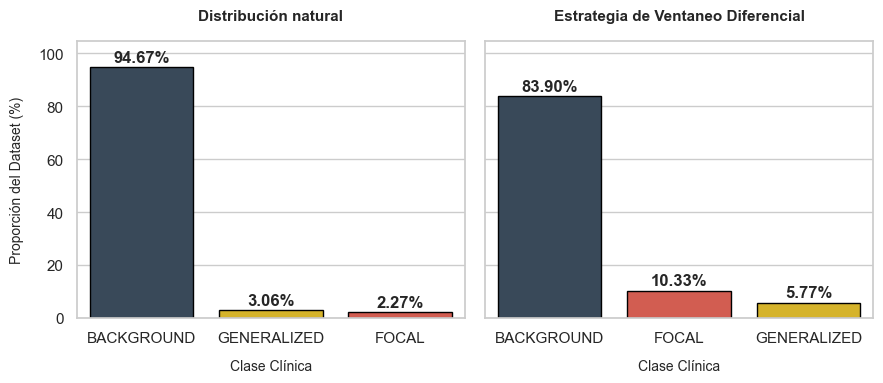

In [70]:
plot_class_comparison(df_original, df_final)

Al contrastar ambas distribuciones, se observa que, si bien la relación de magnitud entre los eventos de tipo focal y generalizado mantiene una proporción relativamente estable con un cociente cercano a 1.5, se produce una inversión significativa en la jerarquía de las clases minoritarias. En el estado natural del dataset, las crisis generalizadas presentan una mayor prevalencia sobre las focales (3.06% frente a 2.27%); sin embargo, tras aplicar la estrategia de ventaneo diferencial, la clase focal toma el liderazgo con un 10.33% frente al 5.77% de la clase generalizada.

Esta transición permite hipotetizar que el proceso de segmentación está descartando intervalos críticos de crisis generalizadas al no satisfacer los criterios de inclusión temporal exigidos. Dado que se aplica una regla de cobertura mínima (50% de solapamiento de la ventana), es factible que una proporción considerable de eventos de tipo generalizado esté siendo reclasificada como background. Este fenómeno sugiere que las crisis focales poseen una persistencia temporal o una alineación con el stride que favorece su captura, mientras que las generalizadas podrían estar sufriendo una dilución sistemática durante la etapa de aumento de datos al no alcanzar el umbral de duración necesario para ser validadas como ventanas de crisis.

In [71]:
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display, HTML

def get_detailed_duration_audit(csv_path: str):
    """
    Analiza la micro-distribucion de duraciones por etiqueta clinica.
    """
    print("Analizando micro-distribucion de duraciones (etiquetas especificas)...")
    csv_files = list(Path(csv_path).rglob("*.csv"))
    all_events = []

    for f in tqdm(csv_files, desc="Procesando archivos CSV"):
        try:
            df = pd.read_csv(f, comment='#')
            df.columns = df.columns.str.strip()
            df['duration'] = df['stop_time'] - df['start_time']
            df['label'] = df['label'].str.strip()
            all_events.append(df[['label', 'duration']])
        except Exception:
            continue

    df_all = pd.concat(all_events, ignore_index=True)

    def get_stats(group):
        q1 = group.quantile(0.25)
        q3 = group.quantile(0.75)
        return pd.Series({
            'Frecuencia (N)': group.count(),
            'Promedio (s)': group.mean(),
            'Desv. Est.': group.std(),
            'Min': group.min(),
            'P25': q1,
            'Mediana (s)': group.median(),
            'P75': q3,
            'Max': group.max(),
            'IQR': q3 - q1
        })

    df_stats = df_all.groupby('label')['duration'].apply(get_stats).unstack()
    return df_stats.sort_values(by='Frecuencia (N)', ascending=False)

def render_styled_audit(df_stats):
    """
    Aplica el estilo profesional solicitado a la tabla de auditoria.
    """
    # Reseteamos el indice para que 'label' sea una columna y aplicamos formato
    df_plot = df_stats.reset_index().rename(columns={'label': 'Etiqueta Clínica'})
    
    # Configuracion del estilo (CSS)
    styled_df = df_plot.style.format({
        'Frecuencia (N)': '{:,.0f}',
        'Promedio (s)': '{:.2f}',
        'Desv. Est.': '{:.2f}',
        'Min': '{:.2f}',
        'P25': '{:.2f}',
        'Mediana (s)': '{:.2f}',
        'P75': '{:.2f}',
        'Max': '{:.2f}',
        'IQR': '{:.2f}'
    }).hide(axis='index')

    styled_df = styled_df.set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', '90%'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '10px')]}
    ])

    # Renderizado en HTML centrado
    display(HTML("<h3 style='text-align: center;'>Resumen Estadístico: Duración de Eventos por Etiqueta</h3>"))
    display(HTML("<div style='text-align: center; width: 100%;'>" + styled_df.to_html() + "</div>"))

In [72]:
CSV_PATH = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
df_detallado = get_detailed_duration_audit(CSV_PATH)  
render_styled_audit(df_detallado)

Analizando micro-distribucion de duraciones (etiquetas especificas)...


Procesando archivos CSV:   0%|          | 0/7364 [00:00<?, ?it/s]

Etiqueta Clínica,Frecuencia (N),Promedio (s),Desv. Est.,Min,P25,Mediana (s),P75,Max,IQR
bckg,"131,887",439.98,430.11,0.10,108.95,300.00,601.00,3598.00,492.05
gnsz,"23,804",73.65,177.85,2.57,15.65,30.23,64.91,2448.00,49.26
fnsz,"19,000",56.84,164.46,1.98,13.88,27.00,58.31,3601.00,44.43
cpsz,"3,597",78.34,111.08,2.34,38.16,63.38,93.00,1303.00,54.84
absz,"2,507",7.86,4.14,2.36,5.05,6.43,9.60,26.43,4.55
spsz,942,33.95,9.53,20.14,30.49,33.72,36.45,97.06,5.96
tcsz,857,74.37,176.92,12.89,45.01,56.34,74.29,2344.05,29.29
tnsz,410,28.01,29.69,5.77,16.58,20.23,26.40,146.89,9.82
mysz,44,646.44,40.90,606.00,606.00,646.43,686.87,686.89,80.87


El análisis estadístico de las duraciones revela una limitación crítica en la metodología inicial: la calibración uniforme del stride y la aplicación de una regla estricta del 50% de solapamiento constituyeron un error de diseño al obviar la variabilidad temporal extrema entre las distintas clases. Mientras que las crisis focales complejas (cpsz) superan holgadamente el minuto de duración mediana, eventos generalizados como las crisis de ausencia (absz) presentan medianas de apenas 6.43 segundos, con un percentil 25 que desciende a 5.05 segundos. Ante una ventana fija de 4 segundos, exigir un mínimo de 2 segundos de solapamiento continuo resulta matemáticamente excluyente para crisis que, por su naturaleza fisiológica, son inherentemente breves. En muchos de estos casos, el evento completo ni siquiera logra cubrir el requisito temporal de la ventana, garantizando su descarte.

En consecuencia, la inversión en la proporción final de las clases —donde las crisis focales pasaron a dominar el dataset procesado con un 10.33% frente al 5.77% de las generalizadas— es un artefacto directo de esta descalibración metodológica. La rigidez de la estrategia de ventaneo actuó involuntariamente como un filtro destructivo, forzando la reclasificación sistemática de las crisis generalizadas cortas como background. Reconocer este sesgo es fundamental para la iteración del modelo, ya que evidencia que la pérdida de representatividad de la clase generalizada no refleja su verdadera prevalencia clínica, sino la incompatibilidad entre la resolución temporal exigida por el algoritmo y la morfología natural de estas crisis.

Para mitigar esta pérdida de información, se descartó la implementación de técnicas de segmentación adaptativa, como los métodos probabilísticos. Aunque teóricamente atractivos, estos enfoques exigen analizar la sesión clínica en su totalidad para delimitar los eventos, lo cual contraviene los lineamientos de diseño orientados al monitoreo continuo y dificulta severamente su integración bajo arquitecturas MLOps en entornos hospitalarios.

En su lugar, se optó por una recalibración paramétrica estática fundamentada en la duración mínima absoluta registrada en el conjunto de datos TUSZ (1.98 segundos). Dado que la crisis más corta no alcanza los 2 segundos, mantener una exigencia tradicional del 50% de solapamiento sobre ventanas de 4 segundos haría matemáticamente imposible su captura. Por ello, se adoptó un criterio de inclusión temporal más laxo, requiriendo que la firma ictal ocupe únicamente el 25% del intervalo (1 segundo). Esta medida garantiza que incluso el evento mínimo genere épocas válidas para el análisis. De manera complementaria, para capitalizar el aumento de datos sobre estos episodios fugaces, se redujo el desfase temporal (stride) de 1 a 0.5 segundos al procesar regiones con actividad de crisis.

La fijación de este umbral de 1 segundo representa un punto de equilibrio técnico crucial. Aplicar una reducción aún más agresiva —por ejemplo, validando ventanas con apenas fracciones de segundo de actividad ictal— resultaría contraproducente. En tales escenarios extremos, la época etiquetada contendría predominantemente actividad de fondo (background), llevando a los modelos predictivos a asociar morfologías normales con la clase patológica. Esto incrementaría drásticamente la tasa de falsos positivos, comprometiendo la viabilidad y confiabilidad de la inferencia durante su despliegue en un entorno clínico real.

# Análisis Cualitativo de Duraciones y la Estructura de las Etiquetas

Al analizar detalladamente la distribución temporal del conjunto de datos, se observa que la inmensa mayoría de las etiquetas clínicas presentan métricas coherentes con su naturaleza fisiológica. Por ejemplo, las crisis de ausencia (absz) registran una mediana de apenas 6.43 segundos, reflejando adecuadamente su carácter breve y transitorio en la práctica médica. De igual forma, eventos de mayor evolución temporal, como las crisis focales (fnsz) o tónico-clónicas (tcsz), muestran medianas de 58.31 y 74.29 segundos respectivamente, valores que se alinean con el desarrollo clínico típico de estas patologías.

Sin embargo, al contrastar estos datos, surge una discrepancia estadística crítica en la clase de las crisis mioclónicas (mysz). A pesar de contar con una muestra de 44 eventos, su duración mínima reportada es de 606.00 segundos (más de 10 minutos), con una mediana de 646.43 segundos. En neurofisiología, una mioclonía discreta es una contracción muscular súbita cuya duración electroencefalográfica se mide en fracciones de segundo. Una duración continua tan extensa para un evento aislado resulta biológicamente inviable.

Esta magnitud atípica sugiere fuertemente que no estamos ante un error de medición algorítmica, sino ante la aplicación de una "macroetiqueta" por parte de los anotadores originales del dataset. Dada la naturaleza de las crisis mioclónicas —que suelen presentarse en ráfagas rápidas y repetitivas—, es una práctica clínica habitual clasificar el intervalo completo de inestabilidad como un periodo o estado mioclónico continuo, en lugar de intentar delimitar cada sacudida de milisegundos de forma individual. En consecuencia, estos registros deben interpretarse no como crisis particulares, sino como extensos bloques de observación que encapsulan descargas intermitentes inmersas en un ritmo de fondo alterado.

Frente a esta realidad metodológica, se determinó la exclusión de la clase mioclónica (mysz) del esquema de clasificación por dos motivos fundamentales. En primer lugar, aunque la dinámica neurofisiológica exacta de estos macro-eventos dentro del registro es incierta y puede variar, someter bloques continuos de más de diez minutos a la estrategia de segmentación por ventanas supone un alto riesgo estructural. En el peor de los casos, esta aproximación provocaría una inclusión masiva de actividad interictal etiquetada erróneamente como patológica. Dado que gran parte de ese extenso intervalo carecería de actividad ictal constante, las características extraídas serían virtualmente indistinguibles del ritmo base. Mantener esta clase contaminaría severamente la categoría de background, confundiendo al clasificador y disparando la tasa de falsos positivos en un entorno de monitorización continua.

En segundo lugar, la remoción de esta clase se plantea como una decisión de diseño fundamentada en el equilibrio entre sensibilidad y estabilidad del algoritmo. Si bien es cierto que excluir estos casos vuelve al modelo relativamente ciego ante este tipo específico de crisis, este costo de oportunidad se asume al considerar su impacto global. Con apenas 44 macro-eventos, las crisis mioclónicas representan una proporción minúscula —aproximadamente un 0.00024%— del volumen total del conjunto de datos. En el desarrollo de sistemas predictivos orientados a la práctica clínica, forzar el aprendizaje de una etiqueta estadísticamente marginal supone un riesgo de desestabilización para la frontera de decisión que supera con creces el beneficio de su inclusión.

In [4]:
def get_mysz_patient_distribution(csv_path: str):
    """
    Rastrea la distribucion de eventos 'mysz' por paciente unico
    para definir la estrategia de exclusion o aislamiento OOD.
    """
    print("Iniciando rastreo de identificadores de paciente para clase mysz...")
    csv_files = list(Path(csv_path).rglob("*.csv"))
    mysz_registry = []

    for f in tqdm(csv_files, desc="Analizando registros"):
        try:
            # En TUSZ, el patient_id suele estar 2 niveles arriba del archivo CSV
            # Estructura: .../patient_id/session_id/file.csv
            patient_id = f.parts[-3] 
            
            df = pd.read_csv(f, comment='#')
            df.columns = df.columns.str.strip()
            
            # Filtrado de eventos especificos
            mask_mysz = df['label'].str.strip() == 'mysz'
            if mask_mysz.any():
                df_mysz = df[mask_mysz].copy()
                for _, row in df_mysz.iterrows():
                    mysz_registry.append({
                        'patient_id': patient_id,
                        'duration': row['stop_time'] - row['start_time'],
                        'file_origin': f.name
                    })
        except Exception:
            continue

    if not mysz_registry:
        print("No se detectaron eventos con la etiqueta 'mysz'.")
        return None

    df_results = pd.DataFrame(mysz_registry)
    
    # Consolidacion de metricas por sujeto
    patient_stats = df_results.groupby('patient_id').agg({
        'file_origin': 'count',
        'duration': ['mean', 'sum']
    })
    
    patient_stats.columns = ['Eventos (N)', 'Duracion Media (s)', 'Duracion Acumulada (s)']
    return patient_stats.sort_values(by='Eventos (N)', ascending=False)

In [7]:
CSV_PATH = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
    
df_distribucion = get_mysz_patient_distribution(CSV_PATH)
    
if df_distribucion is not None:
    print("\nDistribucion de Clase Mioclonica por Sujeto:")
    print(df_distribucion.to_string())
        
    n_pacientes = len(df_distribucion)
    print(f"\nAnalisis de impacto:")
    print(f"Total de pacientes afectados: {n_pacientes}")

Iniciando rastreo de identificadores de paciente para clase mysz...


Analizando registros:   0%|          | 0/7364 [00:00<?, ?it/s]


Distribucion de Clase Mioclonica por Sujeto:
            Eventos (N)  Duracion Media (s)  Duracion Acumulada (s)
patient_id                                                         
aaaaajrs             44          646.435864               28443.178

Analisis de impacto:
Total de pacientes afectados: 1
